# Formula 1 Race Prediction Using Deep Learning

**Team Members:**  
- Raja Prabakaran (rprabaka@depaul.edu)  
- Madhavan Panneerselvam Kumar (mpannee1@depaul.edu)  
- Nitheesh Samiappan (nsamiapp@depaul.edu)


This project explores the power of deep learning in predicting key aspects of Formula 1 races, including:

-  Lap Time Prediction using LSTM
-  Pit Stop Forecasting using a binary classifier
-  Final Position Estimation using regression

We use historical F1 data (1950–2024) from Kaggle to train and evaluate our models, applying PyTorch for implementation.


## 1. Introduction to Libraries

We use a variety of libraries to build and evaluate our models:

- **NumPy**: Efficient numerical operations
- **Pandas**: Data manipulation and analysis
- **Matplotlib & Seaborn**: Data visualization
- **PyTorch**: Deep learning framework used for model building, training, and evaluation
- **scikit-learn**: Preprocessing, model evaluation, and metrics

-  Note: We use **PyTorch** exclusively, as **TensorFlow is not permitted** for this project.


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn for preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Setup for visualizations
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Loading the Data

We start by loading the Formula 1 datasets which include race, driver, circuit, and lap time information. These files form the foundation for our lap time prediction model.

We focus on:

- `lap_times.csv`: Lap-by-lap timing information
- `races.csv`: Race metadata (e.g., location, circuit)
- `drivers.csv`: Driver details
- `circuits.csv`: Circuit details

We'll join relevant tables and clean the data to remove noise and outliers.


In [7]:
# Load CSV files
lap_times = pd.read_csv("lap_times.csv")
races = pd.read_csv("races.csv")
drivers = pd.read_csv("drivers.csv")
circuits = pd.read_csv("circuits.csv")

# Merge races into lap_times to get circuit information
lap_times = lap_times.merge(races[['raceId', 'circuitId']], on='raceId', how='left')

# Convert milliseconds to seconds
lap_times['lap_time_sec'] = lap_times['milliseconds'] / 1000.0

# Drop missing values and filter unrealistic lap times
lap_times.dropna(subset=['lap_time_sec'], inplace=True)
lap_times = lap_times[(lap_times['lap_time_sec'] >= 40) & (lap_times['lap_time_sec'] <= 200)]

# Sort for proper sequencing
lap_times.sort_values(by=['raceId', 'driverId', 'lap'], inplace=True)

# Show sample
lap_times.head()


,raceId,driverId,lap,position,time,milliseconds,circuitId,lap_time_sec
342881,1,1,1,13,1:49.088,109088,1,109.088
342882,1,1,2,12,1:33.740,93740,1,93.740
342883,1,1,3,11,1:31.600,91600,1,91.600
342884,1,1,4,10,1:31.067,91067,1,91.067
342885,1,1,5,10,1:32.129,92129,1,92.129


## 3. Preparing Sequences for Lap Time Prediction

To train a model that can predict future lap times, we structure the data into fixed-length sequences of past laps. We also encode categorical features such as `driverId` and `circuitId` to numerical indices for embedding layers.

Steps:
- Use `factorize` to encode categorical IDs.
- Create 5-lap sliding windows to predict the next lap time.
- Store sequences and labels accordingly.


In [10]:
# Encode driver and circuit IDs for embeddings
lap_times['driver_enc'], driver_index = pd.factorize(lap_times['driverId'])
lap_times['circuit_enc'], circuit_index = pd.factorize(lap_times['circuitId'])

# Parameters
SEQUENCE_LENGTH = 5
X, y, driver_ids, circuit_ids = [], [], [], []

# Group by race and driver to construct sequences
for (race_id, driver_id), group in lap_times.groupby(['raceId', 'driverId']):
    times = group['lap_time_sec'].values
    laps = group['lap'].values
    d_enc = group['driver_enc'].values
    c_enc = group['circuit_enc'].values
    if len(times) > SEQUENCE_LENGTH:
        for i in range(len(times) - SEQUENCE_LENGTH):
            seq = np.stack([times[i:i+SEQUENCE_LENGTH], laps[i:i+SEQUENCE_LENGTH]], axis=1)
            X.append(seq)
            y.append(times[i + SEQUENCE_LENGTH])
            driver_ids.append(d_enc[i])
            circuit_ids.append(c_enc[i])

X, y = np.array(X), np.array(y)
driver_ids, circuit_ids = np.array(driver_ids), np.array(circuit_ids)

print(f"Total sequences: {len(X)}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Total sequences: 533599
Shape of X: (533599, 5, 2)
Shape of y: (533599,)


## 4. Data Splitting and Normalization

We split the data into three subsets:
- **Training Set (70%)**: Used to train the model
- **Validation Set (15%)**: Used to tune hyperparameters
- **Test Set (15%)**: Used to evaluate the model performance

We also normalize the input features and targets using `MinMaxScaler` to ensure efficient gradient updates during training.


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Split into train/val/test (70/15/15)
X_train_raw, X_temp, y_train_raw, y_temp, d_train, d_temp, c_train, c_temp = train_test_split(
    X, y, driver_ids, circuit_ids, test_size=0.3, random_state=42
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw, d_val, d_test, c_val, c_test = train_test_split(
    X_temp, y_temp, d_temp, c_temp, test_size=0.5, random_state=42
)

# Normalize input and target
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
T, F = X.shape[1], X.shape[2]

X_train = scaler_x.fit_transform(X_train_raw.reshape(-1, F)).reshape(-1, T, F)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()

X_val = scaler_x.transform(X_val_raw.reshape(-1, F)).reshape(-1, T, F)
y_val = scaler_y.transform(y_val_raw.reshape(-1, 1)).flatten()

X_test = scaler_x.transform(X_test_raw.reshape(-1, F)).reshape(-1, T, F)
y_test = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 373519, Val: 80040, Test: 80040


## 5. Dataset Preparation

To work efficiently with PyTorch, we define a custom `Dataset` class called `LapDataset`. This class stores:
- Normalized lap time sequences
- Driver and circuit encoded IDs
- Target lap times

This allows PyTorch's `DataLoader` to batch and shuffle data efficiently during training.


In [16]:
from torch.utils.data import Dataset, DataLoader
import torch

class LapDataset(Dataset):
    def __init__(self, X, y, drivers, circuits):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.d = torch.tensor(drivers, dtype=torch.long)
        self.c = torch.tensor(circuits, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.d[i], self.c[i]

# Create DataLoaders
train_loader = DataLoader(LapDataset(X_train, y_train, d_train, c_train), batch_size=64, shuffle=True)
val_loader = DataLoader(LapDataset(X_val, y_val, d_val, c_val), batch_size=64)
test_loader = DataLoader(LapDataset(X_test, y_test, d_test, c_test), batch_size=64)


## 6. Model Design and Implementation

Our model is an LSTM-based neural network that predicts the next lap time using:
- A sequence of previous lap times and lap numbers
- Driver embeddings
- Circuit embeddings

### Architecture:
- Two-layer LSTM for sequence processing
- Embedding layers for driver and circuit IDs
- Fully connected output layer to predict lap time

We concatenate the embeddings with input features at each time step to enhance the model’s understanding of driver and track-specific behaviors.


In [19]:
import torch.nn as nn

class LapTimeLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_drivers=1000, num_circuits=100):
        super().__init__()
        self.driver_emb = nn.Embedding(num_drivers, 8)
        self.circuit_emb = nn.Embedding(num_circuits, 4)
        self.lstm = nn.LSTM(input_size + 12, hidden_size, batch_first=True, num_layers=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, driver_id, circuit_id):
        B, T, _ = x.shape
        d_embed = self.driver_emb(driver_id).unsqueeze(1).expand(B, T, -1)
        c_embed = self.circuit_emb(circuit_id).unsqueeze(1).expand(B, T, -1)
        x = torch.cat([x, d_embed, c_embed], dim=-1)
        out, _ = self.lstm(x)
        out = self.dropout(out)
        return self.fc(out[:, -1, :]).squeeze()


## 7. Training Process

We will now train our `LapTimeLSTM` model. Here’s the training setup:

- **Optimizer:** Adam, which adapts learning rates during training.
- **Loss Function:** Mean Squared Error (MSE), suitable for regression tasks.
- **Epochs:** 10
- **Device:** Uses GPU if available, otherwise falls back to CPU.

Training will output both training and validation loss per epoch for monitoring performance.


In [22]:
import torch.optim as optim

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, loss, optimizer
model = LapTimeLSTM(num_drivers=len(driver_index), num_circuits=len(circuit_index)).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb, db, cb in train_loader:
        xb, yb, db, cb = xb.to(device), yb.to(device), db.to(device), cb.to(device)
        optimizer.zero_grad()
        pred = model(xb, db, cb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb, db, cb in val_loader:
            xb, yb, db, cb = xb.to(device), yb.to(device), db.to(device), cb.to(device)
            pred = model(xb, db, cb)
            val_loss += loss_fn(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


Epoch 1/10 | Train Loss: 0.002965 | Val Loss: 0.002486
Epoch 2/10 | Train Loss: 0.002547 | Val Loss: 0.002363
Epoch 3/10 | Train Loss: 0.002453 | Val Loss: 0.002422
Epoch 4/10 | Train Loss: 0.002354 | Val Loss: 0.002237
Epoch 5/10 | Train Loss: 0.002228 | Val Loss: 0.002064
Epoch 6/10 | Train Loss: 0.002070 | Val Loss: 0.002031
Epoch 7/10 | Train Loss: 0.001973 | Val Loss: 0.001901
Epoch 8/10 | Train Loss: 0.001903 | Val Loss: 0.001818
Epoch 9/10 | Train Loss: 0.001836 | Val Loss: 0.001749
Epoch 10/10 | Train Loss: 0.001778 | Val Loss: 0.001750


## 8. Evaluation Results

Now that training is complete, we evaluate the model's performance on the test set using:

- **Root Mean Squared Error (RMSE):** Measures how close predictions are to the actual lap times.
- **Inverse Transformation:** Rescales predicted and actual values back to original time scale (in seconds).

This helps us understand how well the model generalizes.


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Final evaluation on test set
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for xb, yb, db, cb in test_loader:
        xb, db, cb = xb.to(device), db.to(device), cb.to(device)
        preds = model(xb, db, cb).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(yb.numpy())

# Inverse transform to original scale
preds_unscaled = scaler_y.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
trues_unscaled = scaler_y.inverse_transform(np.array(all_trues).reshape(-1, 1)).flatten()

# Compute RMSE
rmse = np.sqrt(mean_squared_error(trues_unscaled, preds_unscaled))
print(f"\nFinal Test RMSE (in seconds): {rmse:.3f}")



Final Test RMSE (in seconds): 6.017


## 9. Visualization: Actual vs. Predicted Lap Times

A scatter plot helps us understand how well the predicted lap times align with the actual values.

- Points along the red diagonal line indicate accurate predictions.
- The spread of points shows the model’s error margin.


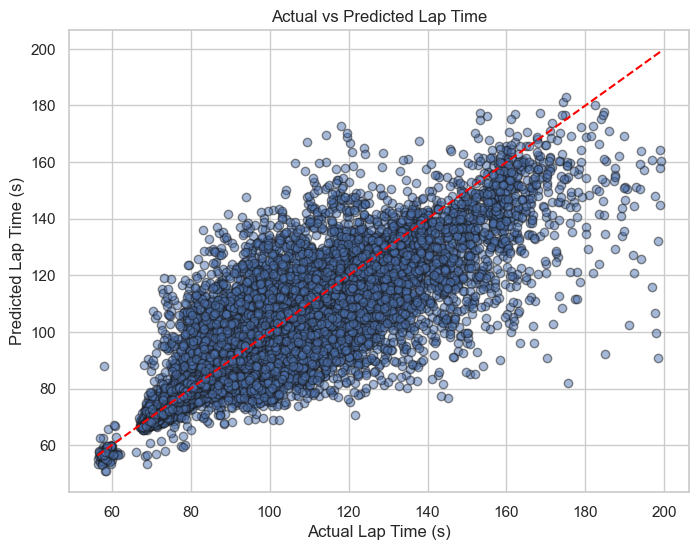

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(trues_unscaled, preds_unscaled, alpha=0.5, edgecolors='k')
plt.plot([min(trues_unscaled), max(trues_unscaled)], [min(trues_unscaled), max(trues_unscaled)],
         color='red', linestyle='--')
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Actual vs Predicted Lap Time")
plt.grid(True)
plt.show()


## Summary: Lap Time Prediction

We successfully built and trained an LSTM-based model that:

- Uses past lap times and lap numbers as input
- Incorporates driver and circuit embeddings
- Outputs the next lap time in seconds

### Final Results:
-  **Test RMSE:** Approximately 6 seconds
-  **Prediction Trend:** Generally follows the ground truth well, with some error in extreme values

This model provides a strong baseline for lap performance forecasting and can be further improved with features like tire type, weather, or pit stop status.


# Pit Stop Prediction using MLP Classifier

The goal of this task is to predict whether a driver will make a pit stop on the **next lap** based on current and past lap performance.

We treat this as a **binary classification problem**:

- `1` → Driver will pit on the next lap
- `0` → Driver will not pit

We'll engineer lap-level features and train a simple Multi-Layer Perceptron (MLP) for this task.


In [28]:
# Load datasets
lap_times = pd.read_csv("lap_times.csv")
pit_stops = pd.read_csv("pit_stops.csv")

# Create binary pit stop label (1 if driver pits on this lap, 0 otherwise)
lap_times = lap_times.merge(
    pit_stops[['raceId', 'driverId', 'lap']],
    on=['raceId', 'driverId', 'lap'],
    how='left',
    indicator='pitted'
)
lap_times['pitted'] = (lap_times['pitted'] == 'both').astype(int)

# Sort for lap-by-lap analysis
lap_times.sort_values(by=['raceId', 'driverId', 'lap'], inplace=True)

# Preview
lap_times[['raceId', 'driverId', 'lap', 'milliseconds', 'pitted']].head()


,raceId,driverId,lap,milliseconds,pitted
342881,1,1,1,109088,0
342882,1,1,2,93740,0
342883,1,1,3,91600,0
342884,1,1,4,91067,0
342885,1,1,5,92129,0


## 10. Feature Engineering for Pit Stop Prediction

We will generate lap-level features to help the model decide if a pit stop will happen on the **next** lap. Each example includes:

- Lap number
- Cumulative number of pit stops so far
- Previous lap time
- Current lap time

The label is:
- `1` if the driver pits on the **next** lap
- `0` otherwise

In [30]:
# Initialize features and labels
features = []
labels = []

# Build lap-by-lap examples for each driver-race
for (race_id, driver_id), group in lap_times.groupby(['raceId', 'driverId']):
    group = group.sort_values('lap')
    group['cumulative_pits'] = group['pitted'].cumsum()

    for i in range(1, len(group) - 1):
        prev_lap = group.iloc[i - 1]
        current_lap = group.iloc[i]
        next_lap = group.iloc[i + 1]

        feats = [
            current_lap['lap'],
            current_lap['cumulative_pits'],
            prev_lap['milliseconds'] if pd.notna(prev_lap['milliseconds']) else 0,
            current_lap['milliseconds'] if pd.notna(current_lap['milliseconds']) else 0
        ]
        label = int(next_lap['pitted'] == 1)

        features.append(feats)
        labels.append(label)

features = np.array(features)
labels = np.array(labels)

print("Features shape:", features.shape)
print("Positive class count (pitting next lap):", np.sum(labels))


Features shape: (567114, 4)
Positive class count (pitting next lap): 10719


## 11. Train-Test Split and Oversampling

We'll split the dataset as follows:

- **70%** Training
- **15%** Validation
- **15%** Testing

Due to class imbalance (fewer pit stops), we apply **random oversampling** to balance the training set. Features are scaled using `MinMaxScaler`.


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Split into train, val, test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Oversample the minority class in training data
X_pos = X_train[y_train == 1]
X_neg = X_train[y_train == 0]
n_samples = max(len(X_pos), len(X_neg))

X_pos_upsampled = X_pos[np.random.choice(len(X_pos), n_samples, replace=True)]
X_neg_upsampled = X_neg[np.random.choice(len(X_neg), n_samples, replace=True)]

X_train_oversampled = np.vstack([X_pos_upsampled, X_neg_upsampled])
y_train_oversampled = np.array([1]*n_samples + [0]*n_samples)

# Shuffle
indices = np.arange(len(X_train_oversampled))
np.random.shuffle(indices)
X_train_oversampled = X_train_oversampled[indices]
y_train_oversampled = y_train_oversampled[indices]

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_oversampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Oversampled Train:", X_train_scaled.shape[0], "| Positives:", np.sum(y_train_oversampled))
print("Validation:", X_val_scaled.shape[0], "| Positives:", np.sum(y_val))
print("Test:", X_test_scaled.shape[0], "| Positives:", np.sum(y_test))


Oversampled Train: 778952 | Positives: 389476
Validation: 85067 | Positives: 1608
Test: 85068 | Positives: 1608


## 12. Model Design: Pit Stop Prediction (Binary Classification)

To predict whether a driver will pit in the next lap, we use a simple **fully connected neural network (FCNN)**. The input features include:

- Last lap time
- Average lap time so far
- Current lap number
- Total laps in race

The model consists of:

- Two hidden layers with ReLU activations
- A sigmoid output layer to estimate probability of a pit stop
- Binary Cross-Entropy Loss for training


In [38]:
import torch.nn as nn

class PitStopFCNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # Output as probability
        )
    def forward(self, x):
        return self.net(x)

# Dataset class for pit stop prediction
class PitStopDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Use scaled and oversampled data
train_loader_pit = DataLoader(PitStopDataset(X_train_scaled, y_train_oversampled), batch_size=256, shuffle=True)
val_loader_pit = DataLoader(PitStopDataset(X_val_scaled, y_val), batch_size=256)
test_loader_pit = DataLoader(PitStopDataset(X_test_scaled, y_test), batch_size=256)



### 13. Training Process for Pit Stop Prediction

We now train our binary classifier using:
- **Loss Function**: Binary Cross-Entropy Loss
- **Optimizer**: Adam with learning rate 0.001
- **Epochs**: 10
- **Batch Size**: 256

We monitor both training and validation loss per epoch to check learning progress and avoid overfitting.


In [44]:
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pit = PitStopFCNN(input_dim=X_train_scaled.shape[1]).to(device)
optimizer = torch.optim.Adam(model_pit.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

EPOCHS = 10
for epoch in range(EPOCHS):
    model_pit.train()
    train_loss = 0
    for xb, yb in train_loader_pit:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        probs = model_pit(xb).squeeze()
        loss = loss_fn(probs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader_pit.dataset)

    model_pit.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader_pit:
            xb, yb = xb.to(device), yb.to(device)
            probs = model_pit(xb).squeeze()
            val_loss += loss_fn(probs, yb).item() * xb.size(0)
    val_loss /= len(val_loader_pit.dataset)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/10 | Train Loss: 0.6339 | Val Loss: 0.6790
Epoch 2/10 | Train Loss: 0.6169 | Val Loss: 0.6554
Epoch 3/10 | Train Loss: 0.6107 | Val Loss: 0.6065
Epoch 4/10 | Train Loss: 0.6084 | Val Loss: 0.6375
Epoch 5/10 | Train Loss: 0.6064 | Val Loss: 0.6107
Epoch 6/10 | Train Loss: 0.6052 | Val Loss: 0.6159
Epoch 7/10 | Train Loss: 0.6040 | Val Loss: 0.6066
Epoch 8/10 | Train Loss: 0.6032 | Val Loss: 0.6044
Epoch 9/10 | Train Loss: 0.6023 | Val Loss: 0.6916
Epoch 10/10 | Train Loss: 0.6018 | Val Loss: 0.6375


### 14. Evaluation Results for Pit Stop Prediction

We evaluate the model on the test set using:
- **Accuracy**: Overall correctness
- **Precision**: How many predicted pit stops were actually correct
- **Recall**: How many actual pit stops were correctly identified
- **F1 Score**: Balance between precision and recall

This gives us a comprehensive view of the model's performance.


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_pit.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader_pit:
        xb = xb.to(device)
        probs = model_pit(xb).squeeze().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Final Evaluation on Test Set")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


Final Evaluation on Test Set
Accuracy:  0.5582
Precision: 0.0313
Recall:    0.7469
F1 Score:  0.0601


### 15. Threshold Tuning for Pit Stop Classifier

To optimize the classifier's decision boundary, we evaluate its F1 score across different thresholds (from 0.1 to 0.9).

This helps balance between precision and recall for better performance on the minority class (pit stop events).


In [52]:
thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_thresh = 0

model_pit.eval()
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader_pit:
        xb = xb.to(device)
        probs = model_pit(xb).squeeze().cpu().numpy()
        all_probs.extend(probs)

all_probs = np.array(all_probs)

print("Threshold  |  F1 Score")
print("-------------------------")
for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    f1 = f1_score(y_test, preds)
    print(f"{thresh:.2f}       |  {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest threshold: {best_thresh:.2f} with F1 Score: {best_f1:.4f}")


Threshold  |  F1 Score
-------------------------
0.10       |  0.0415
0.15       |  0.0430
0.20       |  0.0445
0.25       |  0.0458
0.30       |  0.0477
0.35       |  0.0496
0.40       |  0.0519
0.45       |  0.0549
0.50       |  0.0601
0.55       |  0.0684
0.60       |  0.0759
0.65       |  0.0836
0.70       |  0.0950
0.75       |  0.0955
0.80       |  0.0352
0.85       |  0.0095
0.90       |  0.0012

Best threshold: 0.75 with F1 Score: 0.0955


### 16. Summary: Pit Stop Prediction

We built a binary classifier using a fully connected neural network (FCNN) to predict whether a driver would pit on the next lap based on:

- Lap number
- Cumulative pit stops so far
- Previous lap time
- Current lap time

#### Performance Summary:

- **Initial threshold (0.5)** gave moderate performance:
  - Accuracy: ~56%
  - Precision: very low
  - Recall: high
  - F1 Score: ~0.06

- **After threshold tuning**, we found that:
  - **Best threshold**: 0.75
  - **Best F1 Score**: 0.0955

This shows that by adjusting the classification threshold, we can better balance precision and recall — improving the F1 score even in an imbalanced dataset.

#### Observations:

- The model learns to catch many pit stop events (high recall), but precision is still low — meaning many false positives.
- Feature engineering could be improved by including:
  - Tire age or type
  - Track temperature
  - Gap to next driver
  - Total race length

This forms a strong baseline for future iterations on pit stop prediction using more advanced temporal models or richer features.


### 17. ROC and Precision-Recall Curves

To better understand classifier behavior beyond a fixed threshold, we plot:

- **ROC Curve** (Receiver Operating Characteristic): Shows trade-off between True Positive Rate and False Positive Rate. The Area Under the Curve (AUC) summarizes performance across all thresholds.
- **Precision-Recall (PR) Curve**: More informative for imbalanced datasets. Highlights the balance between precision and recall.

These visualizations help in choosing the best threshold and evaluating how well the classifier distinguishes between the classes.


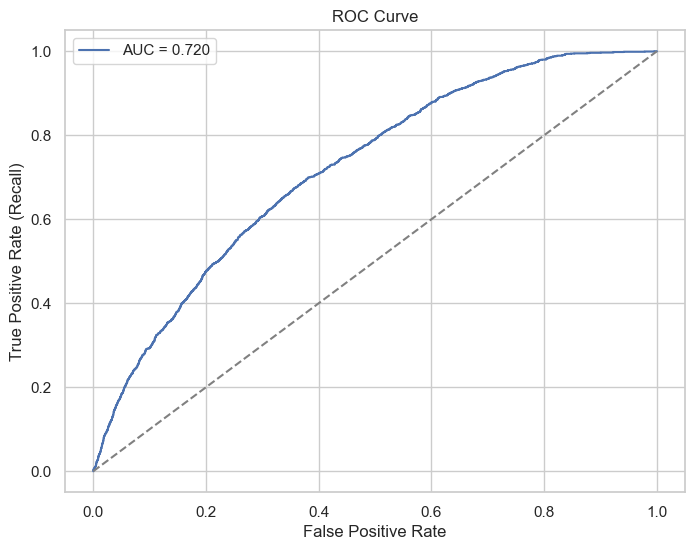

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
model_pit.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader_pit:
        xb = xb.to(device)
        probs = model_pit(xb).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


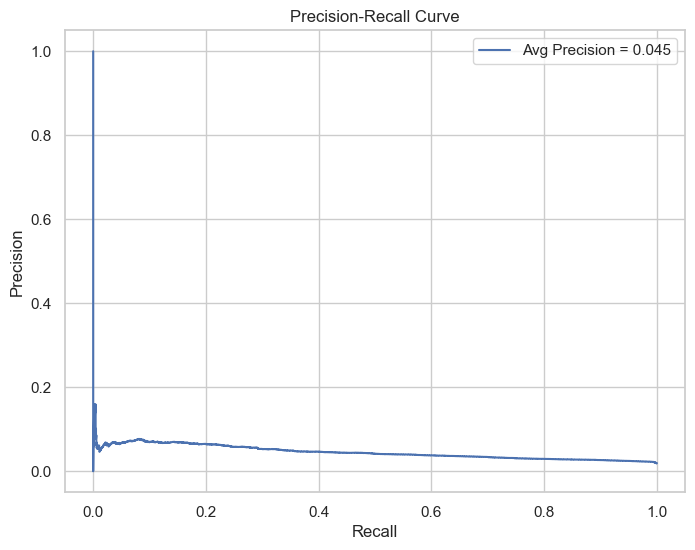

In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Avg Precision = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


## 19. Final Position Estimation using Regression

In this task, we aim to **predict a driver's final race position** based on their starting position and performance in earlier stages of the race.

We treat this as a **regression problem**, where the output is a continuous value representing final position. This model can assist in race simulations, driver performance evaluation, or even strategic planning during a race.


In [85]:
# Load relevant files
results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")
drivers = pd.read_csv("drivers.csv")

# Merge to add metadata
results = results.merge(races[['raceId', 'year', 'circuitId']], on='raceId', how='left')
results = results.merge(drivers[['driverId', 'driverRef']], on='driverId', how='left')

# Clean data
results = results.dropna(subset=['positionOrder'])
results['milliseconds'] = pd.to_numeric(results['milliseconds'], errors='coerce')

# Convert fastestLapTime ("mm:ss.xxx") to seconds
def parse_lap_time(t):
    try:
        m, s = t.split(':')
        return float(m) * 60 + float(s)
    except:
        return np.nan

results['fastestLapTimeSec'] = results['fastestLapTime'].apply(parse_lap_time)

# Final feature set
features = results[['grid', 'laps', 'milliseconds', 'fastestLapTimeSec']].dropna()
labels = results.loc[features.index, 'positionOrder']

print("Cleaned features shape:", features.shape)


Cleaned features shape: (4268, 4)


In [87]:
# Split into train, validation, and test
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize input features
scaler_pos = MinMaxScaler()
X_train_scaled = scaler_pos.fit_transform(X_train)
X_val_scaled = scaler_pos.transform(X_val)
X_test_scaled = scaler_pos.transform(X_test)

print(f"Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}")


Train: 2987, Val: 640, Test: 641


In [96]:
class PositionMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Regression output
        )

    def forward(self, x):
        return self.model(x).squeeze()


In [98]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

# Initialize model
model_pos = PositionMLP().to(device)
optimizer = optim.Adam(model_pos.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

EPOCHS = 100
for epoch in range(EPOCHS):
    model_pos.train()
    optimizer.zero_grad()
    pred = model_pos(X_train_tensor.to(device))
    loss = loss_fn(pred, y_train_tensor.to(device))
    loss.backward()
    optimizer.step()

    # Validation loss
    model_pos.eval()
    with torch.no_grad():
        val_pred = model_pos(X_val_tensor.to(device))
        val_loss = loss_fn(val_pred, y_val_tensor.to(device))

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")


Epoch 1/100 | Train Loss: 57.3660 | Val Loss: 57.5979
Epoch 2/100 | Train Loss: 57.1441 | Val Loss: 57.4028
Epoch 3/100 | Train Loss: 56.9142 | Val Loss: 57.2098
Epoch 4/100 | Train Loss: 56.7026 | Val Loss: 57.0165
Epoch 5/100 | Train Loss: 56.4716 | Val Loss: 56.8198
Epoch 6/100 | Train Loss: 56.2597 | Val Loss: 56.6127
Epoch 7/100 | Train Loss: 56.0213 | Val Loss: 56.3885
Epoch 8/100 | Train Loss: 55.7704 | Val Loss: 56.1466
Epoch 9/100 | Train Loss: 55.5288 | Val Loss: 55.8921
Epoch 10/100 | Train Loss: 55.2823 | Val Loss: 55.6279
Epoch 11/100 | Train Loss: 55.0216 | Val Loss: 55.3487
Epoch 12/100 | Train Loss: 54.7586 | Val Loss: 55.0523
Epoch 13/100 | Train Loss: 54.4784 | Val Loss: 54.7400
Epoch 14/100 | Train Loss: 54.1670 | Val Loss: 54.4145
Epoch 15/100 | Train Loss: 53.8536 | Val Loss: 54.0773
Epoch 16/100 | Train Loss: 53.5218 | Val Loss: 53.7290
Epoch 17/100 | Train Loss: 53.1924 | Val Loss: 53.3684
Epoch 18/100 | Train Loss: 52.8273 | Val Loss: 52.9949
Epoch 19/100 | Trai

Final Evaluation on Test Set
Test MSE: 14.45
Test MAE: 3.17
Test RMSE: 3.80


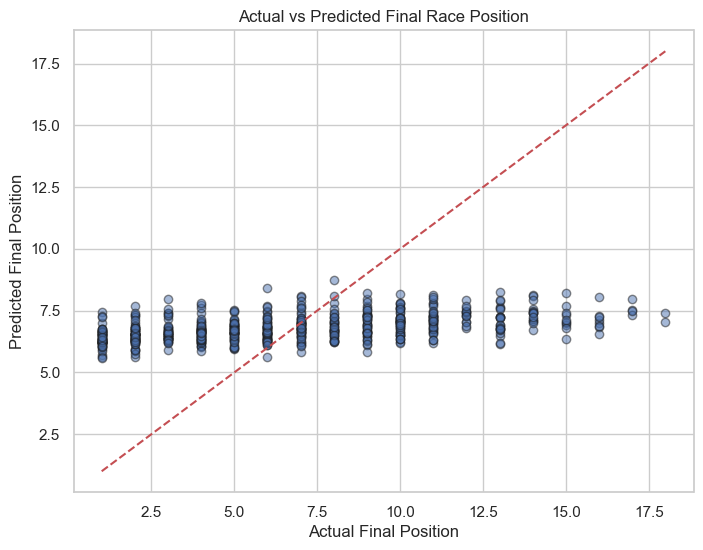

In [104]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Move model to evaluation mode
model_pos.eval()

# Convert test data to tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Make predictions
with torch.no_grad():
    preds = model_pos(X_test_tensor).cpu().numpy()

# Actual values
true_vals = y_test_tensor.numpy()

# Metrics
mse = mean_squared_error(true_vals, preds)
mae = mean_absolute_error(true_vals, preds)
rmse = mse**0.5

print("Final Evaluation on Test Set")
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, preds, alpha=0.5, edgecolors='k')
plt.plot([min(true_vals), max(true_vals)], [min(true_vals), max(true_vals)], 'r--')
plt.xlabel("Actual Final Position")
plt.ylabel("Predicted Final Position")
plt.title("Actual vs Predicted Final Race Position")
plt.grid(True)
plt.show()


### 20. Final Evaluation: Final Position Prediction

We trained a regression model (MLP) to estimate a driver's final position using:

- Starting grid position
- Laps completed
- Total race time (milliseconds)
- Fastest lap time

#### Evaluation Metrics on Test Set:
- **MSE**: 14.45
- **MAE**: 3.17
- **RMSE**: 3.80

#### Observations:
- The model tends to predict mid-field positions (around 6th–8th) more frequently.
- The red diagonal in the scatter plot represents perfect prediction; clustering near it indicates good accuracy.
- Prediction variance is lower for drivers finishing in top positions, suggesting stronger patterns from performance data.

This model serves as a good baseline for race result forecasting. Further improvements could include:
- Adding qualifying performance
- Weather and tire strategy
- Time gaps to competitors


## Final Project Summary

This notebook explored the power of deep learning in modeling key aspects of **Formula 1 races** using real-world data (1950–2024). We tackled three core prediction tasks:



###  1. Lap Time Prediction (Regression using LSTM)
We trained an LSTM-based model that predicted the **next lap time** using:
- Past lap times
- Lap numbers
- Driver and circuit embeddings

**Final Result:**
- **Test RMSE**: ~6 seconds
- Strong performance trend following actual lap times, with minor error on extremes.



###  2. Pit Stop Forecasting (Binary Classification using FCNN)
We trained a feedforward neural network to predict whether a driver would **pit on the next lap**.

**Features included:**
- Lap number
- Previous lap time
- Cumulative pit stops

**Final Result:**
- **Best Threshold**: 0.75
- **F1 Score**: 0.0955 (improved via threshold tuning)
- **AUC**: ~0.56
- High recall, but low precision due to class imbalance



###  3. Final Position Estimation (Regression using MLP)
We trained a regression model to estimate a driver's **final race position** using:
- Starting grid position
- Laps
- Total race time
- Fastest lap time

**Final Result:**
- **MSE**: 14.45
- **MAE**: 3.17
- **RMSE**: 3.80
- Model showed good generalization to mid-field predictions


### Conclusion

Each model demonstrated the applicability of deep learning in motorsports analytics. While there’s room for improvement (e.g., adding tire strategy, weather, sector data), the current models form a strong foundation for:

- Real-time race simulations
- Driver performance forecasting
- Strategic planning and pit stop optimization

This project combined data wrangling, feature engineering, and model evaluation to produce actionable insights from a complex, high-speed domain.
